# Judge tie rates

One row per judge model, one dot per (configuration × track), placed at the share of pairwise
comparisons that judge called a tie. It answers "which judge ties, and how far does the
ablation move that" in a glance, which the per-ablation tables cannot. The same numbers are
written out as a CSV and as the paper's LaTeX table, so the figure and the table cannot drift
apart — they are built in the same run, from the same DataFrame.

Numbers come from the `unified_pairwise*.json` chart data in the merge directories, the same
files [two_track_figure.ipynb](two_track_figure.ipynb) reads, so a row here is the row of the
same name there and the two figures cannot disagree about what a configuration did. Nothing is
recomputed: a cell is that run's `n_ties` over its own `support`, as the merge recorded it.

Everything the figure says — tracks, rows, judges, labels, geometry, where it is written — lives
in the one config cell below. This replaces the old `chart_tie_rates.py` and `table_tie_rates.py`
pair.

Two things to keep in mind when editing `ROWS`. Ties only exist in the pairwise setup, so that
is the only setup read — which is also why the pairwise-only P3–P5 rows need no special
handling here, unlike in the two-track figure. And a tie needs an even number of votes to be
reachable at all, so the sampling-depth ablations (`unidirectional`, one vote, can never tie;
`mec_k_1`, two votes, ties whenever the directions disagree) are not on the same scale as the
rest and are left out.

In [7]:
import json
import re
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "src").is_dir() and (p / "output").is_dir()
)
sys.path.insert(0, str(ROOT / "src"))

# The typeface, the Type-42 font settings, the cells no judge can honour, the
# per-track ablation naming, where the chart data lives and the save path — all
# shared with the sibling figures, so a regenerated panel cannot drift from the
# ones beside it.
from novelty_eval.figures.common import (
    FONT_STACK, PDF_RCPARAMS, UNSUPPORTED_CELLS, chart_data_path, row_key,
    save_figure)

In [8]:
# ---- everything the figure says, in one place --------------------------------

# Tracks, in legend order: display name -> (merge directory under
# output/ablation_sweeps, name token). The token fills {track} in a panel name,
# for an ablation whose instance set differs per track. The same directories and
# the same tokens two_track_figure names its tracks with.
TRACKS = {
    "Human-only": ("merge_hvh_all_metrics", "human"),
    "Human + generated": ("merge_vanilla_all_metrics", "vanilla"),
}

# Which accuracy report the merge read: "filtered" or "unfiltered". Filtered is
# what the two-track figures draw, and its runs all share one support.
VARIANT = "filtered"
SETUP = "pairwise"                # the only setup with ties to report

# Rows, top to bottom: (panel name, label). `None` is the un-ablated run every
# panel carries as its baseline. Panel names and labels are two_track_figure's,
# minus the line breaks its row labels wrap at — here a label is a table row and
# a CSV field, not a two-line cell. Anything in the data and not listed here is
# reported as not drawn: that is how the generator-backbone panels, and the
# sampling-depth ones whose tie rates are not comparable (see the note at the
# top), stay out.
ROWS = [
    (None, "Reference"),
    ("vague_criterion", "P1 · Criteria without guardrails"),
    ("no_criteria_prompt", "P2 · Criteria removed"),
    ("ai_researcher_base", 'P3 · "Which was judged novel?"'),
    ("ai_researcher_no_review", 'P4 · "Which is novel?"'),
    ("ai_researcher_comparative", 'P5 · "Which was judged more novel?"'),
    ("retrieval", "+ Related work (retrieval)"),
    ("low_judge_reasoning", "Reasoning effort = low"),
    ("mec_k_1", "No verdict aggregation"),
    ("convert_to_plan_form_{setup}_{track}", "Idea as research plan"),
]

# Judge columns, left to right: name in the data -> label, as the figure says it.
JUDGES = {
    "claude-sonnet-4-5": "sonnet-4-5",
    "claude-opus-4-5": "opus-4-5",
    "claude-opus-4-6": "opus-4-6",
    "gpt-5.1": "gpt-5.1",
    "gpt-5.2": "gpt-5.2",
    "gpt-5.4": "gpt-5.4",
}

# And as the LaTeX table says it. Twelve judge columns have to fit the page
# width, and a header is what sets its column's width, so the table names judges
# short and the caption spells them out — the sentence that does is generated
# from this map, so the two cannot drift apart.
TABLE_JUDGES = {
    "claude-sonnet-4-5": "son-4-5",
    "claude-opus-4-5": "op-4-5",
    "claude-opus-4-6": "op-4-6",
    "gpt-5.1": "5.1",
    "gpt-5.2": "5.2",
    "gpt-5.4": "5.4",
}

# A sentence appended to the caption, for what the numbers cannot say themselves
# — why a cell is blank, say. The read cell above prints which cells are blank
# and why. "" appends nothing.
CAPTION_NOTE = ("The reasoning-effort row is blank for son-4-5: the model exposes "
                "no reasoning-effort control, so that configuration is not "
                "defined for it.")

# Blue/orange survives the common colour-vision deficiencies and stays separable
# in greyscale; check a third hue against both before adding a track.
TRACK_COLORS = {"Human-only": "#2a78d6", "Human + generated": "#eb6834"}

# Layout in inches, so a row is the height it says it is and there is no layout
# engine to reverse-engineer when it looks wrong. Type is at caption size: the
# figure sits next to body text and the LaTeX caption is its title.
WIDTH_IN = 7.1                    # about full text width
ROW_IN = 0.33                     # height of one judge row
MARGIN_IN = {"left": 0.95,        # room for the judge names and the axis title
             "right": 0.10,
             "top": 0.42,         # room for the legend, above the axes
             "bottom": 0.46}      # room for the tick labels and the axis title
FONT_SIZES = {"row": 9, "tick": 8, "axis": 9, "legend": 8.5}
DOT = {"size": 21,                # marker area in points squared
       "edge": 0.6,               # white outline, so overlapping dots stay countable
       "spread": 0.15}            # furthest a dot is pushed off its row line, in rows
XLABEL = "Tie rate (share of pairs judged a tie)"
YLABEL = "Judge model"

# Output subdirectory under output/figures/, and the filename stem. The variant
# lands in the name too, so switching it writes a new set of files instead of
# overwriting the last one.
FIGURE = "tie-rates"
FORMATS = [".pdf", ".png"]        # PDF is vector, PNG is what displays inline
TABLE_LABEL = "tab:tie_rates"     # \label{} of the LaTeX table
FIGURE_REF = "fig:tie_rates"      # what its caption points at

In [9]:
# ---- read the merge directories ----------------------------------------------

DATA = {track: json.loads(
            chart_data_path(ROOT / "output/ablation_sweeps" / merge_dir,
                            SETUP, VARIANT).read_text())
        for track, (merge_dir, _token) in TRACKS.items()}


def panel_name(panel, token):
    """A row's panel name in one track; None stays None, the un-ablated baseline."""
    return None if panel is None else panel.format(setup=SETUP, track=token)


def baseline_metrics(panels, judge):
    """Every panel in a track carries the same baseline, so the first panel that
    has this judge answers for all of them."""
    return next((p["baseline_metrics"][judge] for p in panels.values()
                 if judge in p["baseline_metrics"]), {})


rows, notes = [], []
for track, (_merge_dir, token) in TRACKS.items():
    panels = DATA[track]["panels"]
    for panel, label in ROWS:
        name = panel_name(panel, token)
        if name is not None and name not in panels:
            notes.append(f"{track}: no panel {name!r} — row {label!r} left blank")
            continue
        for judge in JUDGES:
            if (row_key(name or ""), judge) in UNSUPPORTED_CELLS:
                notes.append(f"{track}: {judge} has no such control — {label}")
                continue
            metrics = (baseline_metrics(panels, judge) if name is None
                       else panels[name]["ablation_metrics"].get(judge, {}))
            ties, support = metrics.get("n_ties"), metrics.get("support")
            if ties is None or not support:
                notes.append(f"{track}: no tie count for {judge} — {label}")
                continue
            rows.append({"track": track, "row": label, "panel": name or "baseline",
                         "judge": judge, "ties": int(ties), "support": int(support),
                         "rate": ties / support})

runs = pd.DataFrame(rows)
print(f"{len(runs)} runs: {runs.row.nunique()} configurations x "
      f"{runs.judge.nunique()} judges x {runs.track.nunique()} tracks")
print(f"support per run: {runs.support.min()}–{runs.support.max()} pairs\n")

# Everything in the merge that this figure does not draw, and every cell it could
# not fill, so a typo in the config cell is one glance away rather than a missing
# dot to go hunting for.
for track, (_merge_dir, token) in TRACKS.items():
    drawn = {panel_name(panel, token) for panel, _ in ROWS}
    left_out = [p for p in DATA[track]["panels"] if p not in drawn]
    print(f"not drawn  {track:<18} {', '.join(left_out) or '—'}")
for note in notes:
    print(f"no cell    {note}")

118 runs: 10 configurations x 6 judges x 2 tracks
support per run: 154–154 pairs

not drawn  Human-only         unidirectional
not drawn  Human + generated  gpt_5.1_backbone_pairwise_vanilla, gpt_5.4_backbone_pairwise_vanilla, opus-4-5_backbone_pairwise_vanilla, unidirectional
no cell    Human-only: claude-sonnet-4-5 has no such control — Reasoning effort = low
no cell    Human + generated: claude-sonnet-4-5 has no such control — Reasoning effort = low


In [10]:
# ---- the numbers, before anything is drawn ------------------------------------
# Rows are configurations, columns are judges within a track block, cells are tie
# rates in percent. This is the table the figure plots and the .tex writes out: if
# a dot or a cell looks wrong, the reason is visible here.

table = (
    runs.assign(pct=runs.rate * 100)
    .pivot(index="row", columns=["track", "judge"], values="pct")
    .reindex(index=[label for _, label in ROWS],
             columns=pd.MultiIndex.from_product([list(TRACKS), list(JUDGES)],
                                                names=["track", "judge"]))
    .rename(columns=JUDGES)
)
table.index.name = None
with pd.option_context("display.width", 220, "display.max_columns", None):
    print(table.round(1))

track                               Human-only                                           Human + generated                                          
judge                               sonnet-4-5 opus-4-5 opus-4-6 gpt-5.1 gpt-5.2 gpt-5.4        sonnet-4-5 opus-4-5 opus-4-6 gpt-5.1 gpt-5.2 gpt-5.4
Reference                                 12.3      4.5      0.6     6.5     3.2     4.5              35.1     18.2      3.2     7.1     2.6     5.2
P1 · Criteria without guardrails          29.2      5.2      3.2     1.9     3.2     1.9              52.6     21.4      5.2     7.8     8.4     3.9
P2 · Criteria removed                     27.3     11.0      4.5     2.6     2.6     3.9              57.8     24.7      7.1     6.5     3.9     2.6
P3 · "Which was judged novel?"            12.3     11.7     11.0     1.9     4.5     4.5              11.7      6.5      0.0     6.5     5.2     2.6
P4 · "Which is novel?"                    12.3     24.7     35.7     6.5     5.8     4.5              16.2

output/figures/tie-rates/tie-rates_filtered.pdf
output/figures/tie-rates/tie-rates_filtered.png


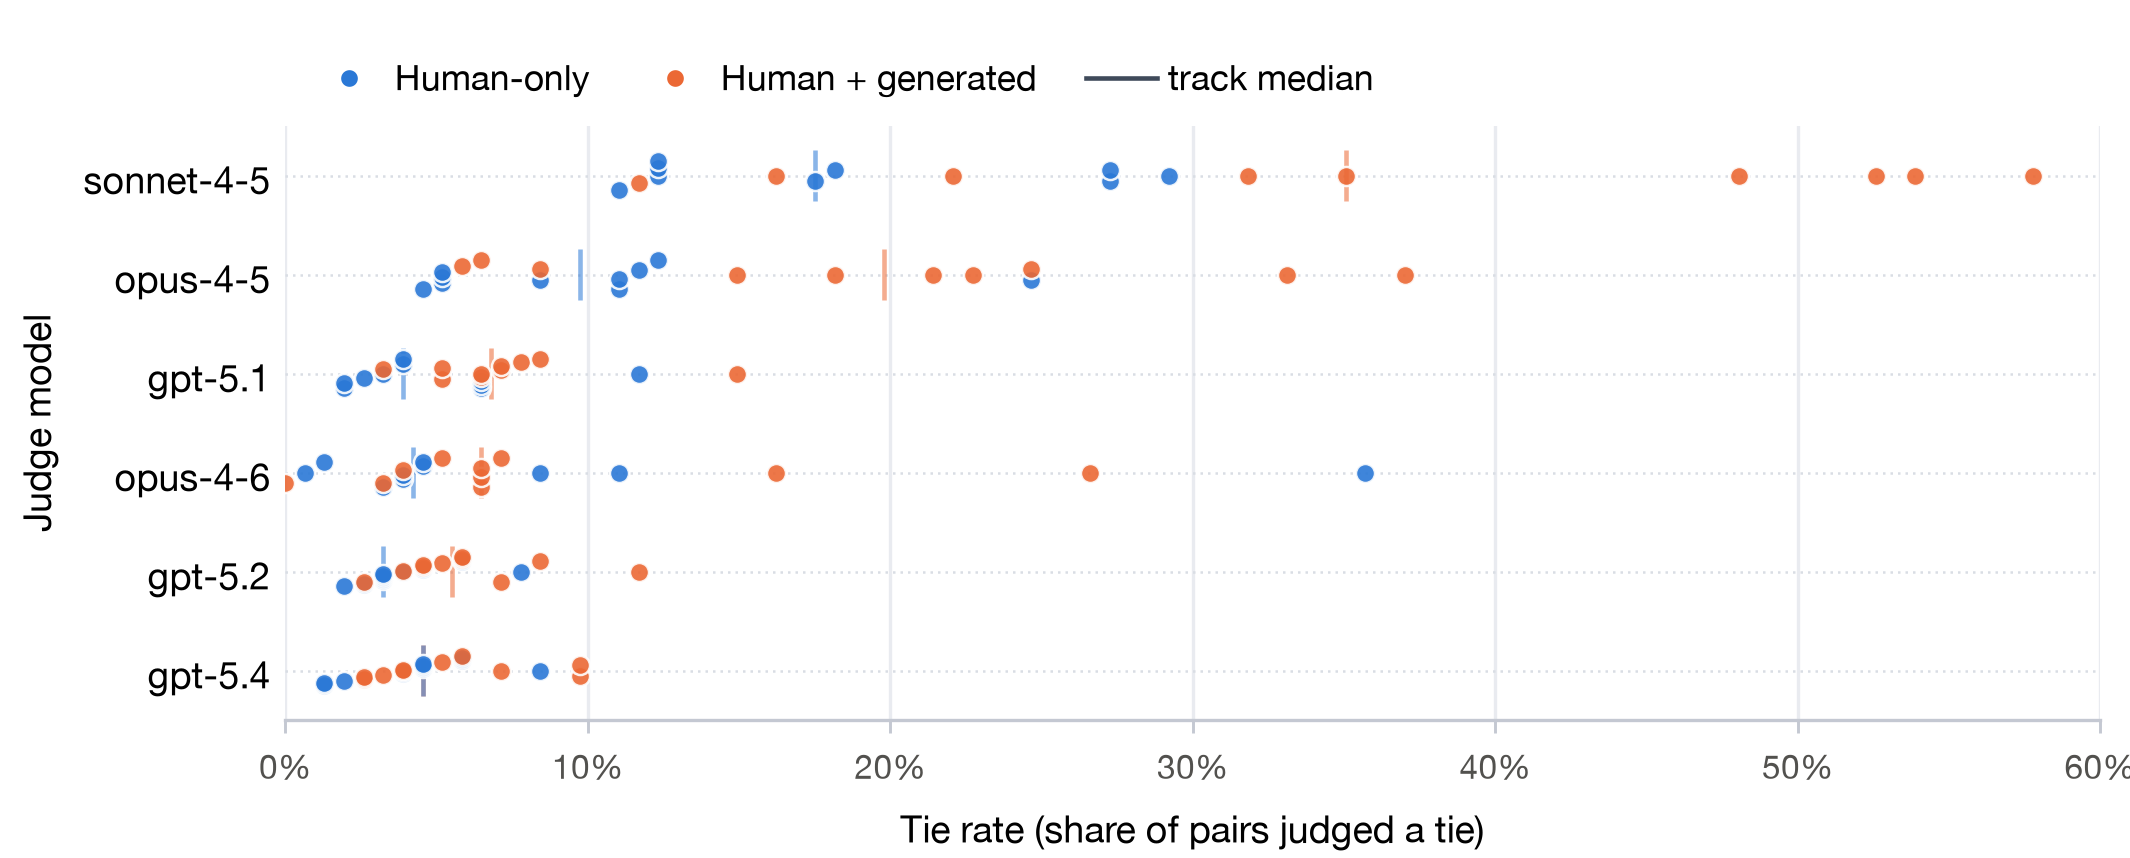

In [11]:
# ---- the figure ---------------------------------------------------------------
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({"font.family": "sans-serif",
                     "font.sans-serif": FONT_STACK, **PDF_RCPARAMS})

# Rows top to bottom: the judge that ties most first, which is the comparison
# between judges the figure is making.
order = list(runs.groupby("judge").rate.median().sort_values(ascending=False).index)
xmax = min(1.0, (int(runs.rate.max() * 10) + 1) / 10)


def row_offsets(rates, min_gap, spread):
    """Vertical offsets that stop overlapping dots hiding each other.

    Dots are walked left to right and pushed off the row line only while a
    neighbour sits within min_gap, so an isolated dot stays on its line and a row
    of well-separated dots reads as a clean strip.
    """
    offsets = [0.0] * len(rates)
    clusters, cluster = [], []
    for i in sorted(range(len(rates)), key=lambda i: rates[i]):
        if cluster and rates[i] - rates[cluster[-1]] > min_gap:
            clusters.append(cluster)
            cluster = []
        cluster.append(i)
    clusters.append(cluster)
    for cluster in clusters:
        step = min(2 * spread / max(len(cluster) - 1, 1), 0.11)
        for rank, i in enumerate(cluster):
            offsets[i] = (rank - (len(cluster) - 1) / 2) * step
    return offsets


fig_h = ROW_IN * len(order) + MARGIN_IN["top"] + MARGIN_IN["bottom"]
fig = plt.figure(figsize=(WIDTH_IN, fig_h))
ax = fig.add_axes([MARGIN_IN["left"] / WIDTH_IN, MARGIN_IN["bottom"] / fig_h,
                   1 - (MARGIN_IN["left"] + MARGIN_IN["right"]) / WIDTH_IN,
                   ROW_IN * len(order) / fig_h])

for i, judge in enumerate(order):
    y = len(order) - 1 - i                      # first judge at the top
    points = runs[runs.judge == judge]
    ax.axhline(y, color="#d9dde4", lw=0.6, ls=(0, (1, 2)), zorder=1)
    # The dots show the spread the configurations produce; the tick shows where
    # the judge sits once that spread is collapsed. Drawn under the dots, but
    # taller than they are fanned, so its ends stay visible when one lands on it.
    for track, track_points in points.groupby("track"):
        ax.vlines(track_points.rate.median(), y - DOT["spread"] * 1.7,
                  y + DOT["spread"] * 1.7, color=TRACK_COLORS[track],
                  lw=1.1, alpha=0.55, zorder=2)
    rates = list(points.rate)
    for rate, track, dy in zip(rates, points.track,
                               row_offsets(rates, xmax * 0.018, DOT["spread"])):
        ax.scatter(rate, y + dy, s=DOT["size"], color=TRACK_COLORS[track],
                   edgecolor="white", linewidth=DOT["edge"], alpha=0.9, zorder=3)

ax.set_yticks(range(len(order)), [JUDGES[j] for j in reversed(order)],
              fontsize=FONT_SIZES["row"])
ax.set_ylim(-0.5, len(order) - 0.5)
ax.set_xlim(0, xmax)
ticks = [t / 100 for t in range(0, int(round(xmax * 100)) + 1, 10)]
ax.set_xticks(ticks, [f"{round(t * 100)}%" for t in ticks],
              fontsize=FONT_SIZES["tick"])
ax.set_xlabel(XLABEL, fontsize=FONT_SIZES["axis"], labelpad=5)
ax.set_ylabel(YLABEL, fontsize=FONT_SIZES["axis"], labelpad=6)
ax.xaxis.grid(True, color="#e9ebf0", lw=0.8)
ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#c4c8d2")
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", color="#c4c8d2", labelcolor="#52514e", length=3, width=0.7)

handles = [Line2D([], [], marker="o", ls="", markersize=5, markerfacecolor=colour,
                  markeredgecolor="white", label=track)
           for track, colour in TRACK_COLORS.items()]
handles.append(Line2D([], [], color="#3f4a5a", lw=1.1, label="track median"))
ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(0, 1.0),
          borderaxespad=0.4, ncol=len(handles), frameon=False,
          fontsize=FONT_SIZES["legend"], handletextpad=0.3, columnspacing=1.4)

OUT_DIR = ROOT / "output/figures" / FIGURE
STEM = f"{FIGURE}_{VARIANT}"
written = save_figure(fig, OUT_DIR / (STEM + FORMATS[0]), formats=FORMATS[1:])
print(*[p.relative_to(ROOT) for p in written], sep="\n")
display(Image(filename=str(next(p for p in written if p.suffix == ".png"))))

In [12]:
# ---- the same numbers as a CSV and as the paper's table -----------------------
# Thirteen columns is wide even for a table*, so the table is cut to fit rather
# than scaled down to fit: short judge headers set in the body face (typewriter
# type is about a quarter wider per character, and twelve of those columns is
# what pushed it off the page), tight column padding, and none at all outside the
# first and last column. That measures 431pt against the 455pt of an ACL page, so
# it fits without a \resizebox shrinking the type out of step with the rest of
# the paper. Widen a label or add a judge and it will need checking again.

MEAN_LABEL = r"\textit{Mean}"
TABCOLSEP = "3pt"                 # space either side of every column
BLOCK_GAP = r"@{\hspace{8pt}}"    # between two tracks, so the blocks read apart


def latex_escape(text):
    """Row labels are written for the figure, not for TeX: quote them properly and
    escape what would otherwise be markup."""
    for char in "&%$#_":
        text = text.replace(char, "\\" + char)
    text = text.replace("\u00b7", r"$\cdot$")   # no encoding for TeX to depend on
    return re.sub(r'"([^"]*)"', r"``\1''", text)


def latex_table(table, supports):
    """One row per configuration, one column block per track, a mean row at the foot.

    The column padding is kept in the .tex source too, so the `&` line up for
    whoever ends up reading the table by hand.
    """
    judges = [TABLE_JUDGES[judge] for judge in JUDGES]   # table order = figure order
    names = [latex_escape(label) for label in table.index] + [MEAN_LABEL]
    width = max(len(name) for name in names)

    def body_row(name, values):
        cells = " & ".join("    " if pd.isna(v) else f"{v:>4.1f}" for v in values)
        return f"{name:<{width}} & {cells} " + r"\\"

    col_spec = "@{}l " + BLOCK_GAP.join(["c" * len(judges)] * len(TRACKS)) + "@{}"
    blocks = " & ".join(
        rf"\multicolumn{{{len(judges)}}}{{c}}{{\textbf{{{track}}}}}" for track in TRACKS)
    rules = " ".join(
        rf"\cmidrule(lr){{{2 + k * len(judges)}-{1 + (k + 1) * len(judges)}}}"
        for k in range(len(TRACKS)))
    judge_row = " & ".join(judges * len(TRACKS))
    named = ", ".join(rf"{short} is \texttt{{{judge}}}"
                      for judge, short in TABLE_JUDGES.items())
    # The caption may only claim one n when every cell really shares one.
    n_note = (f" Every cell is computed over the same $n = {supports[0]}$ pairwise "
              f"examples, so the number of ties is the rate $\\times\\,{supports[0]}$."
              if len(supports) == 1 else
              f" Support varies between {min(supports)} and {max(supports)} pairs, "
              f"so each rate is over its own run's support.")
    return "\n".join([
        r"\begin{table*}[!htb]",
        r"\centering",
        r"\footnotesize",
        r"\setlength{\tabcolsep}{" + TABCOLSEP + "}",
        f"\\begin{{tabular}}{{{col_spec}}}",
        r"\toprule",
        f"& {blocks} " + r"\\",
        rules,
        r"\textbf{Configuration} & " + judge_row + r" \\",
        r"\midrule",
        *[body_row(name, table.loc[label])
          for name, label in zip(names, table.index)],
        r"\midrule",
        body_row(MEAN_LABEL, table.mean()),
        r"\bottomrule",
        r"\end{tabular}",
        r"\caption{\textbf{Tie rates (\%) across controlled configurations}, the "
        f"numbers behind Figure~\\ref{{{FIGURE_REF}}}. Judges are abbreviated: "
        f"{named}.{n_note}" + (f" {CAPTION_NOTE}" if CAPTION_NOTE else "") + "}",
        f"\\label{{{TABLE_LABEL}}}",
        r"\end{table*}",
        "",
    ])


csv_path = OUT_DIR / f"{STEM}.csv"
runs.to_csv(csv_path, index=False)

tex_path = OUT_DIR / f"{STEM}.tex"
tex = latex_table(table, sorted(runs.support.unique()))
tex_path.write_text(tex, encoding="utf-8")

print(csv_path.relative_to(ROOT), tex_path.relative_to(ROOT), "", sep="\n")
print(tex)

output/figures/tie-rates/tie-rates_filtered.csv
output/figures/tie-rates/tie-rates_filtered.tex

\begin{table*}[!htb]
\centering
\footnotesize
\setlength{\tabcolsep}{3pt}
\begin{tabular}{@{}l cccccc@{\hspace{8pt}}cccccc@{}}
\toprule
& \multicolumn{6}{c}{\textbf{Human-only}} & \multicolumn{6}{c}{\textbf{Human + generated}} \\
\cmidrule(lr){2-7} \cmidrule(lr){8-13}
\textbf{Configuration} & son-4-5 & op-4-5 & op-4-6 & 5.1 & 5.2 & 5.4 & son-4-5 & op-4-5 & op-4-6 & 5.1 & 5.2 & 5.4 \\
\midrule
Reference                                   & 12.3 &  4.5 &  0.6 &  6.5 &  3.2 &  4.5 & 35.1 & 18.2 &  3.2 &  7.1 &  2.6 &  5.2 \\
P1 $\cdot$ Criteria without guardrails      & 29.2 &  5.2 &  3.2 &  1.9 &  3.2 &  1.9 & 52.6 & 21.4 &  5.2 &  7.8 &  8.4 &  3.9 \\
P2 $\cdot$ Criteria removed                 & 27.3 & 11.0 &  4.5 &  2.6 &  2.6 &  3.9 & 57.8 & 24.7 &  7.1 &  6.5 &  3.9 &  2.6 \\
P3 $\cdot$ ``Which was judged novel?''      & 12.3 & 11.7 & 11.0 &  1.9 &  4.5 &  4.5 & 11.7 &  6.5 &  0.0 &  6.5 